In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import UnivariateSpline
import json

In [75]:
def plot_pair_training_curve(target_path, dependent_path, title, metric_name = "Accuracy", x_max=None, labels=[], normalize=False, log=False):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t")
    plt.figure(figsize=(24, 6))
    # make the x axis logarithmic
    #plt.yscale('log')
    for index, row in df_target.iterrows():
        x_target, y_target = [int(x) for x in df_target.columns[1:]], row[1:]
        # normalize the y_target values by the first value of y_target
        if normalize:
            y_target = [(y - y_target.iloc[0]) / (y_target.iloc[-1] - y_target.iloc[0]) for y in y_target]
        if log:
            y_target = np.log(y_target)
        if x_max is not None:
            x_target = x_target[:x_max]
            y_target = y_target[:x_max]
        spline = UnivariateSpline(x_target, y_target, s=0.1)
        y_smooth = spline(x_target)
        if len(labels) > 0:
            plt.plot(x_target, y_smooth, label=labels[0], color='black')
        else:
            plt.plot(x_target, y_target, label=f'Dataset 1')
        #plt.plot(x_target, y_smooth, label=f'Layer {index+1} Target')

        x_dependent, y_dependent = [int(x) for x in df_dep.columns[1:]], df_dep.iloc[index][1:]
        if x_max is not None:
            x_dependent = x_dependent[:x_max]
            y_dependent = y_dependent[:x_max]
        if normalize:
            y_dependent = [(y - y_dependent.iloc[0]) / (y_dependent.iloc[-1] - y_dependent.iloc[0]) for y in y_dependent]
        if log:
            y_dependent = np.log(y_dependent)
        if len(labels) > 0:
            plt.plot(x_dependent, y_dependent, label=labels[1], color='red')
        else:
            plt.plot(x_dependent, y_dependent, label=f'Dataset 2')
    
    # draw a vertical line at x = 20000
    plt.axvline(x=2100, color='r', linestyle='--')

    plt.xlabel('Step')
    plt.ylabel(metric_name)
    #plt.yticks([0.5, 0.6, 0.8, 0.85, 0.9, 0.95, 1])
    plt.xticks(np.arange(min(x_dependent), max(x_dependent)+1, 100))
    plt.title(title)
    plt.legend()
    plt.show()

In [3]:
def plot_pair_training_curve_twinx(target_path, dependent_path, title, metric_name="Accuracy", x_max=None, labels=[], normalize=False):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t")

    fig, ax1 = plt.subplots(figsize=(24, 6))
    
    # Plot on left y-axis (ax1)
    for index, row in df_target.iterrows():
        x_target, y_target = [int(x) for x in df_target.columns[1:]], row[1:]
        if normalize:
            y_target = [(y - y_target.iloc[0]) / (y_target.iloc[-1] - y_target.iloc[0]) for y in y_target]
        
        if x_max is not None:
            x_target = x_target[:x_max]
            y_target = y_target[:x_max]
        
        ax1.plot(x_target, y_target, label=labels[0] if len(labels) > 0 else 'Dataset 1', color='blue')
    
    ax1.set_xlabel('Step')
    ax1.set_ylabel(f'{metric_name} (Target)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Add second y-axis (ax2)
    ax2 = ax1.twinx()
    
    for index, row in df_dep.iterrows():
        x_dependent, y_dependent = [int(x) for x in df_dep.columns[1:]], df_dep.iloc[index][1:]
        if normalize:
            y_dependent = [(y - y_dependent.iloc[0]) / (y_dependent.iloc[-1] - y_dependent.iloc[0]) for y in y_dependent]

        if x_max is not None:
            x_dependent = x_dependent[:x_max]
            y_dependent = y_dependent[:x_max]

        ax2.plot(x_dependent, y_dependent, label=labels[1] if len(labels) > 0 else 'Dataset 2', color='green')
    
    ax2.set_ylabel(f'{metric_name} (Dependent)', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Add vertical line
    ax1.axvline(x=2100, color='r', linestyle='--')

    plt.title(title)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.show()


# Ditransitives

## Number of tokens in top 75%

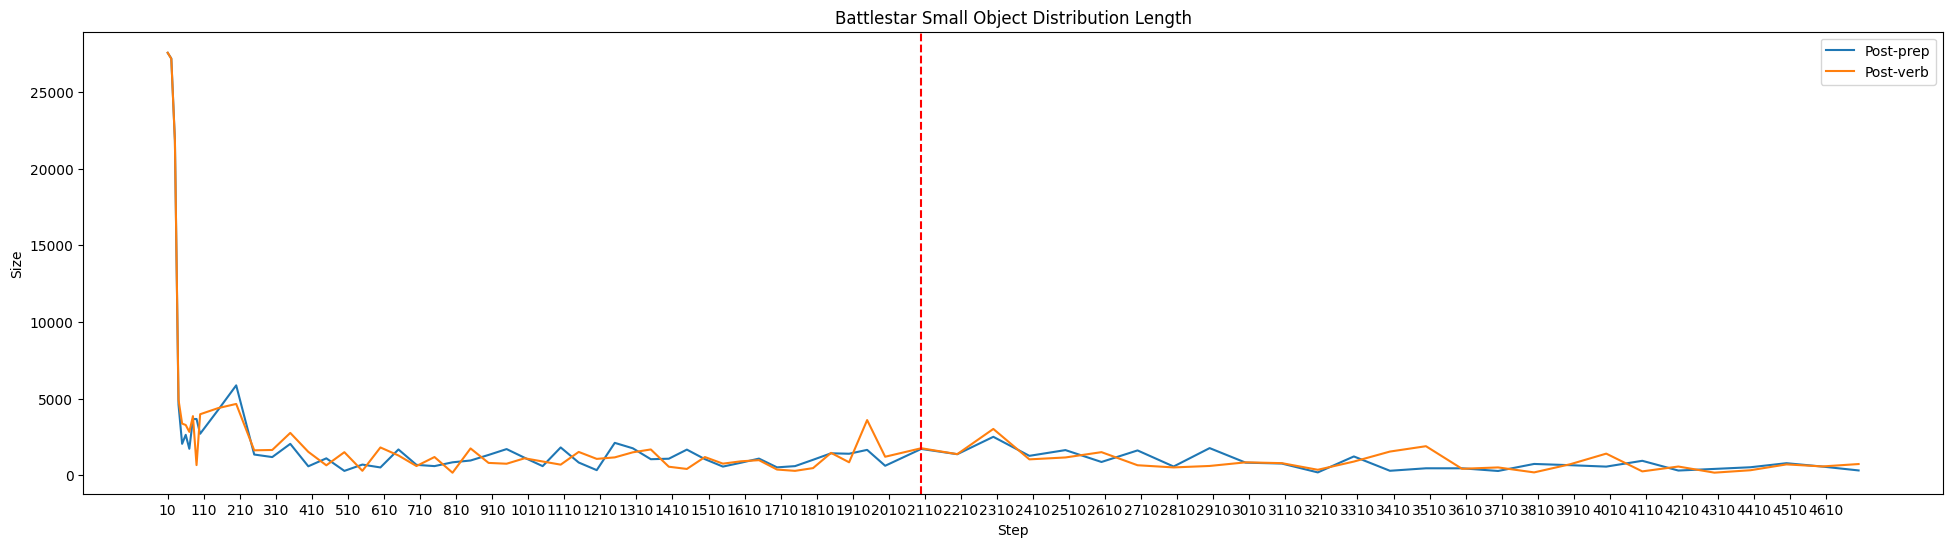

In [4]:
post_prep = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.length.preposition_fragment.tsv"
post_verb = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/verb_fragment/battlestar_small.object_distribution.length.verb_fragment.tsv"

plot_pair_training_curve(post_prep, post_verb, "Battlestar Small Object Distribution Length", metric_name="Size", labels=["Post-prep", "Post-verb"], x_max=75, normalize=False)

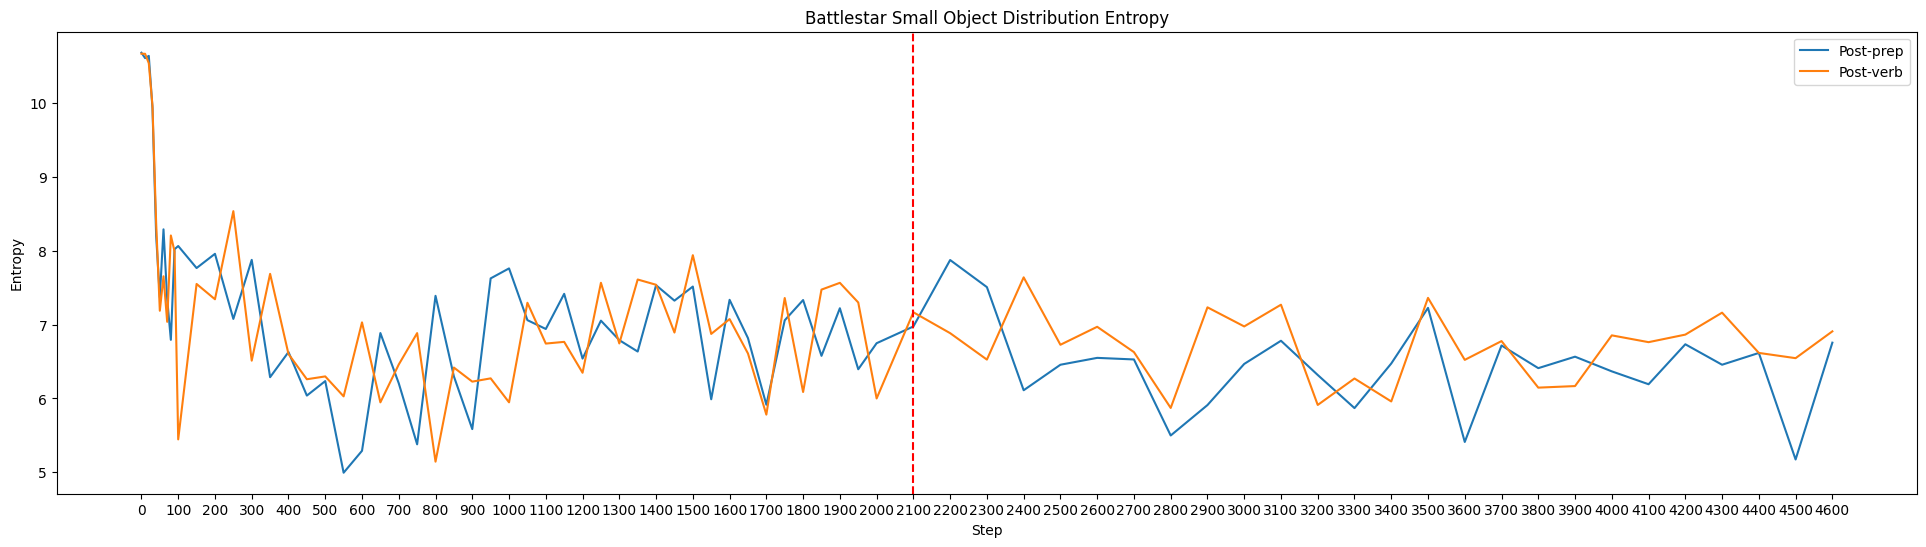

In [9]:
post_prep = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.tsv"
post_verb = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/verb_fragment/battlestar_small.object_distribution.entropy.verb_fragment.tsv"

plot_pair_training_curve(post_prep, post_verb, "Battlestar Small Object Distribution Entropy", metric_name="Entropy", labels=["Post-prep", "Post-verb"], x_max=75, normalize=False, log=False)

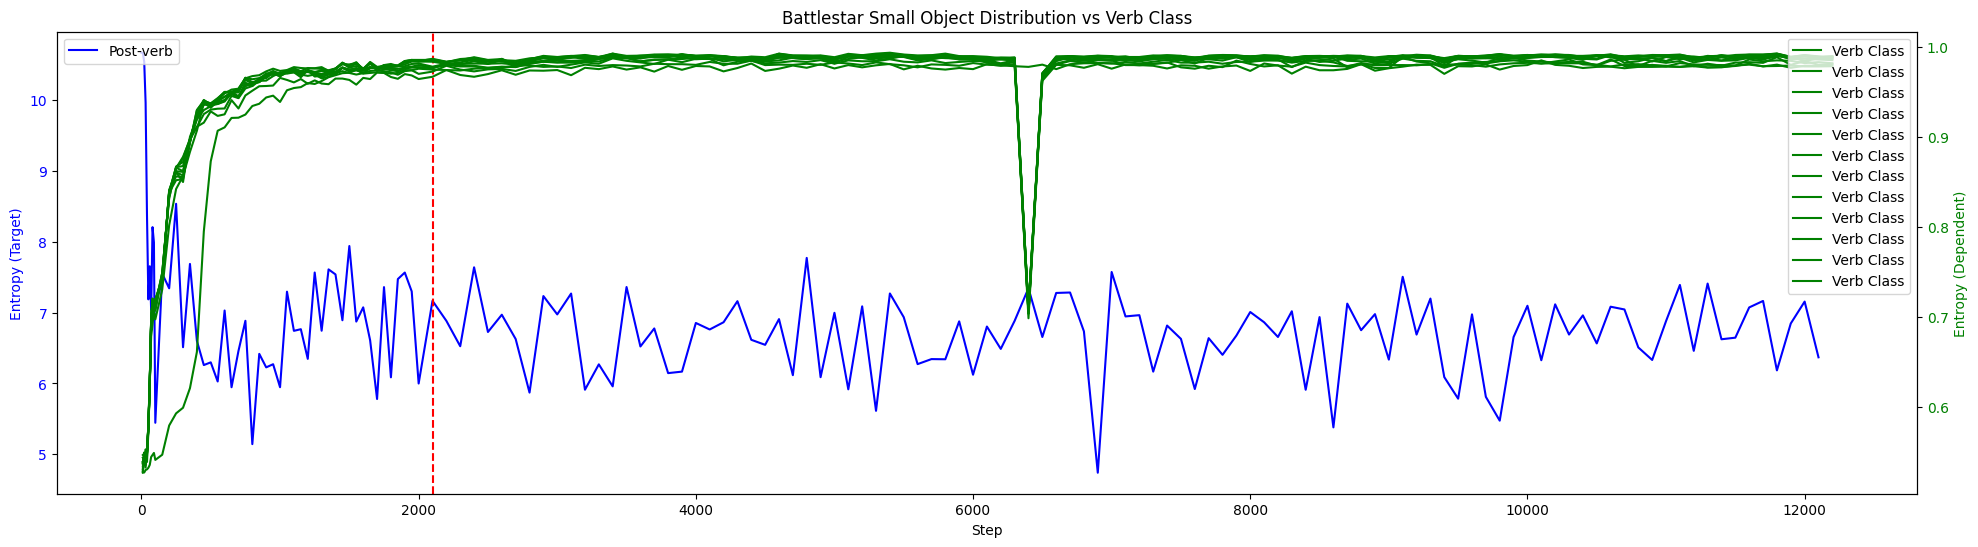

In [5]:
post_verb = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/verb_fragment/battlestar_small.object_distribution.entropy.verb_fragment.tsv"
verb_class = "/sailhome/jjian/projects/abstraction/results/wikitext/to/pca_4/battlestar_small.motion_balanced.ditrans_balanced.dependent.tsv"

plot_pair_training_curve_twinx(post_verb, verb_class, "Battlestar Small Object Distribution vs Verb Class", metric_name="Entropy", labels=["Post-verb", "Verb Class"], x_max=150, normalize=False)

# TODO: Verb-by-Verb analysis, vs. Class-by-class

In [34]:
# load the data from csv
data_path = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"
df = pd.read_csv(data_path, sep="\t", index_col=0)
# make sure all the columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')
results = pairwise_t_tests(df)
# save the above to a csv file
results.to_csv("/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.t_test.tsv",sep="\t", index=False)

In [63]:
motion_sampled = "/nlp/scr/jjian/datasets/wikitext_parsed/motion.parsed_filtered.balanced_sampled.json"
motion_json = json.load(open(motion_sampled, "r"))

from collections import Counter
verb_list = [d["dependent_lemma"] for d in motion_json]
verb_counter = Counter(verb_list)
common_motion = verb_counter.most_common(35)
common_motion_list = [x[0] for x in common_motion]

In [6]:
# load the data from csv
data_path1 = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"
df1 = pd.read_csv(data_path1, sep="\t", index_col=0)
# make sure all the columns are numeric
df1 = df1.apply(pd.to_numeric, errors='coerce')
# load the data from csv
data_path2 = "/sailhome/jjian/projects/abstraction/results/wikitext/motion/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"
df2 = pd.read_csv(data_path2, sep="\t", index_col=0)
# make sure all the columns are numeric
df2 = df2.apply(pd.to_numeric, errors='coerce')
df2 = df2.loc[common_motion_list]
# delete rows from df2 if they are not in common_motion
# concatenate the two dataframes
df = pd.concat([df1, df2], axis=0)
# drop the last column
df = df.iloc[:, :-1]
# drop the first 5 columns
df = df.iloc[:, 5:]
df
results = pairwise_t_tests(df)
# save the above to a csv file
#results.to_csv("/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.t_test.motion.ditrans.tsv",sep="\t", index=False)

In [69]:
ditransitives_list = list(df1.index)
motion_list = list(df2.index)

# get the percentage of significant differences if p-value < 0.05 if both verbs are drawn from the same list
ditransitive_significant = 0
ditransitive_total = 0
motion_significant = 0
motion_total = 0
cross_significant = 0
cross_total = 0

for index, row in results.iterrows():
    if row['Row1'] in ditransitives_list and row['Row2'] in ditransitives_list:
        ditransitive_total += 1
        if row['P-Value'] < 0.05:
            ditransitive_significant += 1
    elif row['Row1'] in motion_list and row['Row2'] in motion_list:
        motion_total += 1
        if row['P-Value'] < 0.05:
            motion_significant += 1
    else:
        cross_total += 1
        if row['P-Value'] < 0.05:
            cross_significant += 1

# print percentages
print(f"Percentage of significant differences between ditransitives: {ditransitive_significant / ditransitive_total}")
print(f"Percentage of significant differences between motion verbs: {motion_significant / motion_total}")
print(f"Percentage of significant differences between ditransitives and motion verbs: {cross_significant / cross_total}")

Percentage of significant differences between ditransitives: 0.2722689075630252
Percentage of significant differences between motion verbs: 0.43529411764705883
Percentage of significant differences between ditransitives and motion verbs: 0.356734693877551


In [16]:
# write a function to graph the raw data

def plot_raw_data(data_path, title, metric_name="Entropy", x_max=None):
    df = pd.read_csv(data_path, sep="\t", index_col=0)
    df = df.apply(pd.to_numeric, errors='coerce')
    plt.figure(figsize=(24, 6))
    for index, row in df.iterrows():
        x, y = [int(x) for x in df.columns], row
        if x_max is not None:
            x = x[:x_max]
            y = y[:x_max]
        plt.plot(x, y, label=f'{index}')
    plt.xlabel('Step')
    plt.ylabel(metric_name)
    plt.xticks(np.arange(min(x), max(x)+1, 100))
    plt.title(title)
    plt.legend()


The conclusion that we can draw based on the data below is that next token entropy is driven by something other than the lexical identity of the predicate. Behaviourly, this is not what we expect from the VIH, I think. Now we should compare across classes.

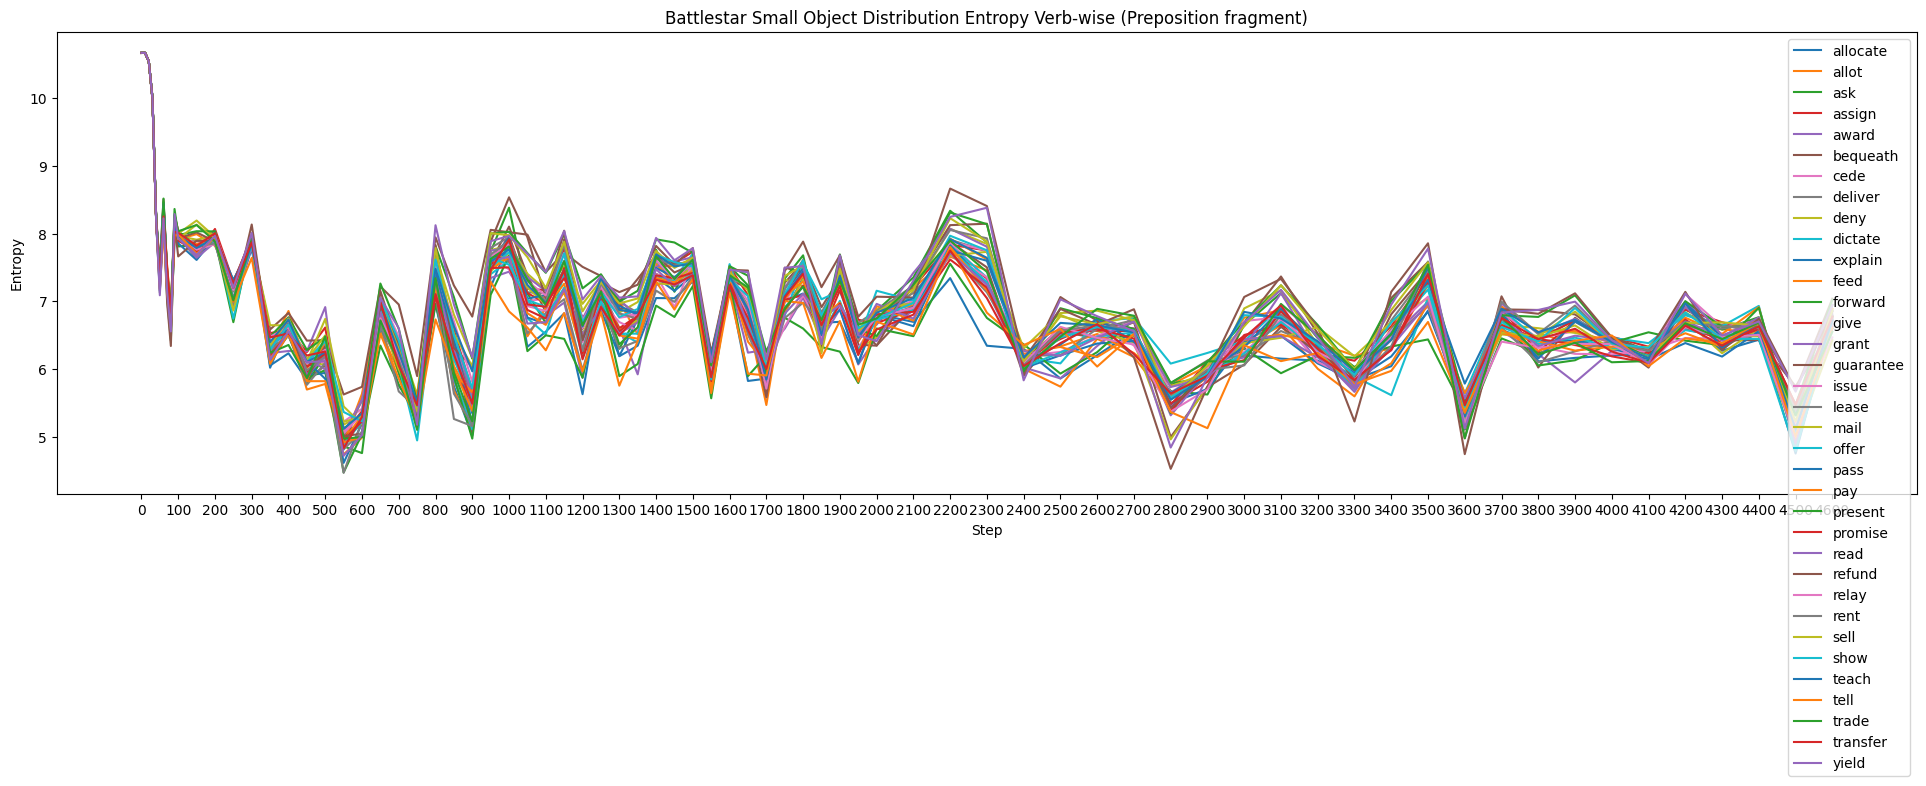

In [18]:
plot_raw_data(data_path1, "Battlestar Small Object Distribution Entropy Verb-wise (Preposition fragment)", metric_name="Entropy", x_max=75)

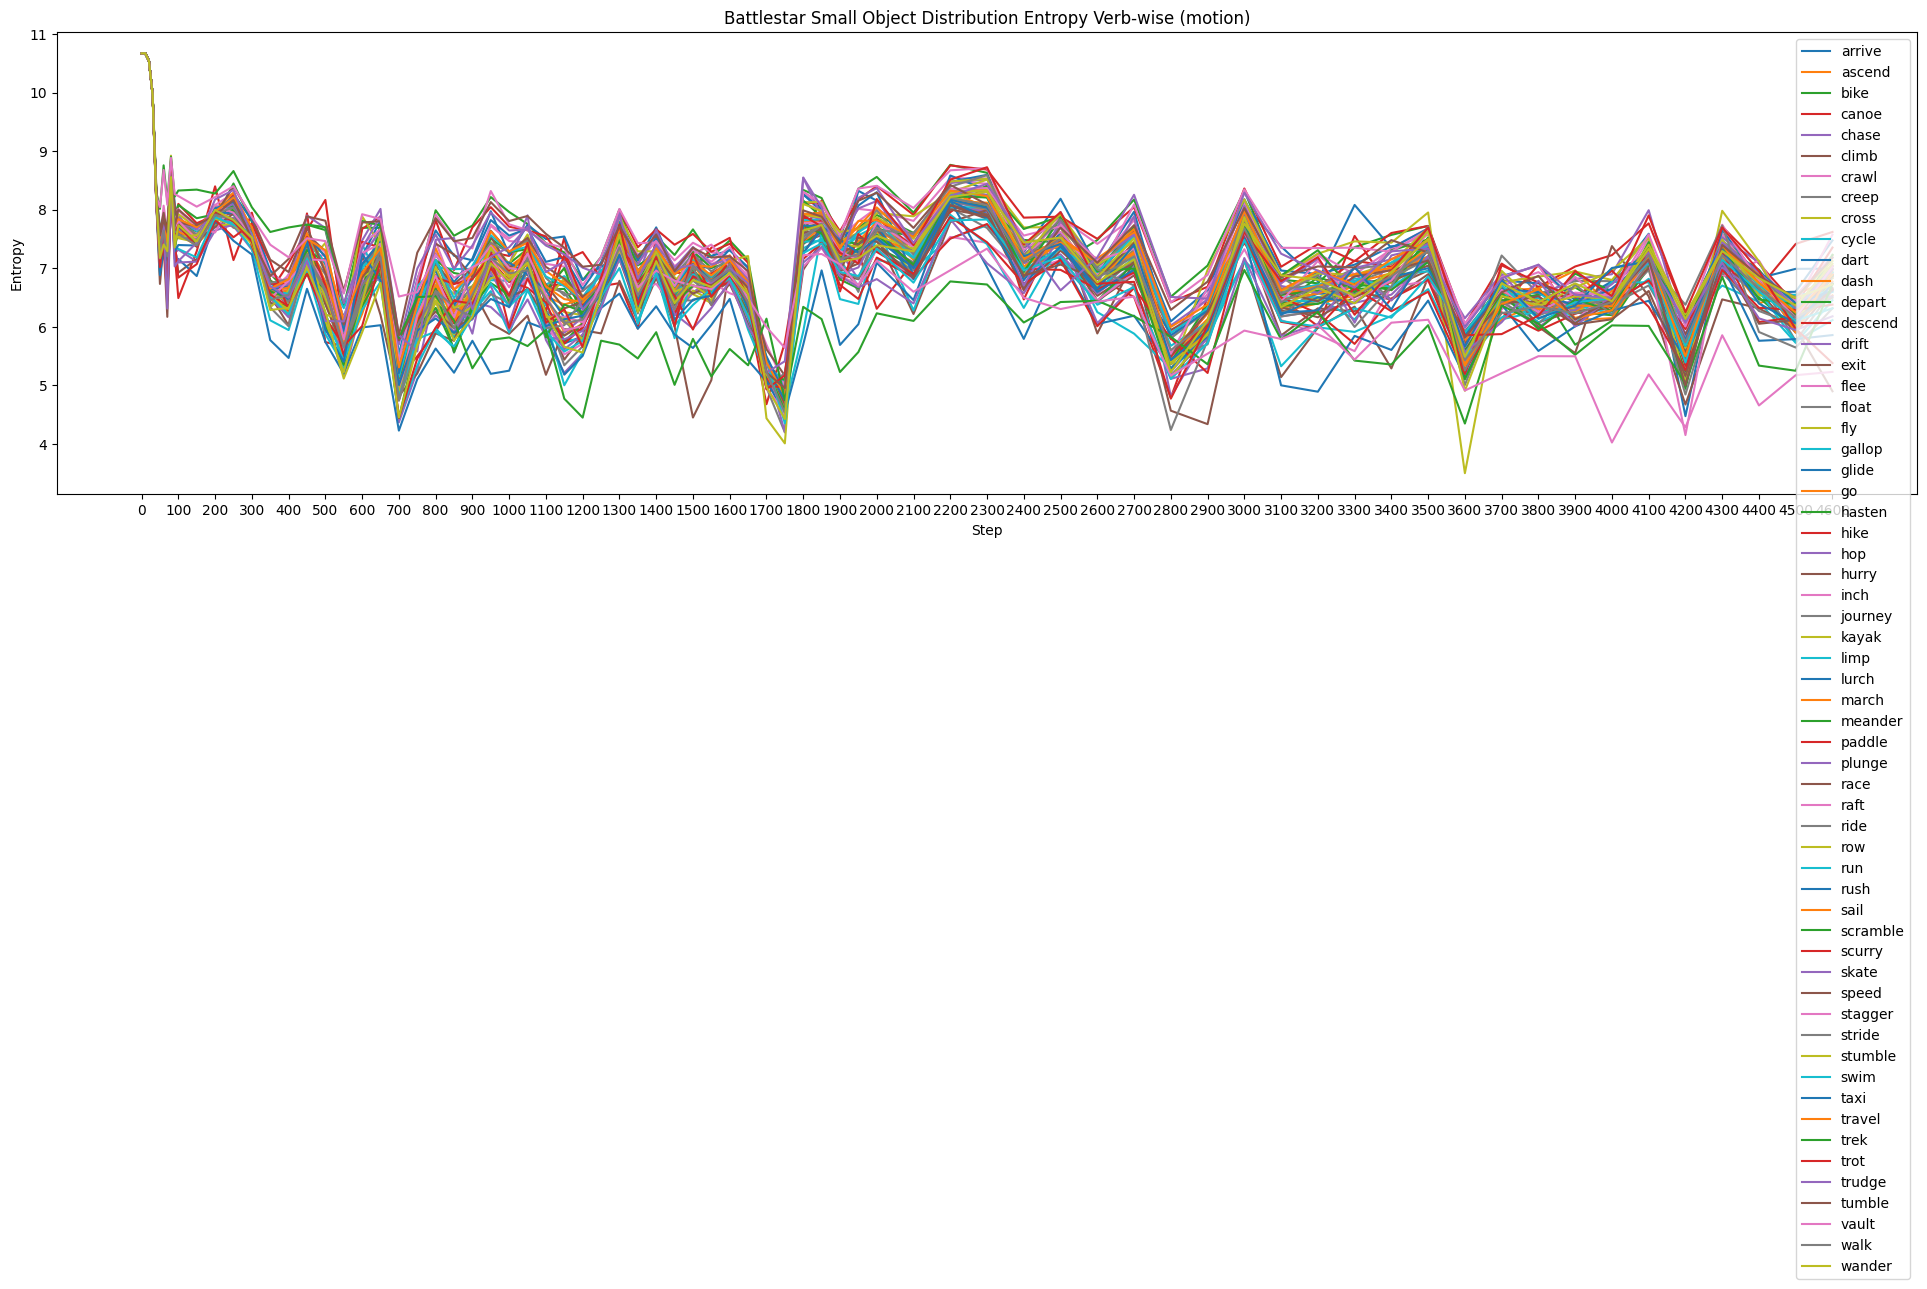

In [54]:
data_path = "/sailhome/jjian/projects/abstraction/results/wikitext/motion/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"
plot_raw_data(data_path, "Battlestar Small Object Distribution Entropy Verb-wise (motion)", metric_name="Entropy", x_max=75)

In [33]:
verb_counter

Counter({'ascend': 93,
         'walk': 93,
         'climb': 93,
         'rush': 93,
         'run': 93,
         'travel': 93,
         'go': 93,
         'swim': 92,
         'ride': 92,
         'flee': 92,
         'cross': 92,
         'march': 92,
         'sail': 92,
         'descend': 92,
         'fly': 92,
         'drift': 79,
         'arrive': 70,
         'hurry': 49,
         'race': 47,
         'float': 35,
         'journey': 31,
         'depart': 25,
         'crawl': 23,
         'row': 16,
         'taxi': 15,
         'limp': 14,
         'glide': 13,
         'hasten': 12,
         'chase': 12,
         'plunge': 12,
         'dash': 12,
         'scramble': 12,
         'wander': 11,
         'cycle': 11,
         'hike': 10,
         'skate': 10,
         'tumble': 10,
         'stumble': 9,
         'meander': 8,
         'creep': 7,
         'stagger': 7,
         'paddle': 6,
         'speed': 5,
         'lurch': 5,
         'inch': 5,
         'gallop'

In [12]:
motion_sampled = "/nlp/scr/jjian/datasets/wikitext_parsed/motion.parsed_filtered.balanced_sampled.json"
motion_json = json.load(open(motion_sampled, "r"))

from collections import Counter
verb_list = [d["dependent_lemma"] for d in motion_json]
verb_counter = Counter(verb_list)
common_motion = verb_counter.most_common(35)
common_motion_list = [x[0] for x in common_motion]

def plot_pair_training_curve(target_path, dependent_path, title, metric_name = "Accuracy", x_max=None, labels=[], normalize=False, log=False):
    df_target = pd.read_csv(target_path, sep="\t")
    df_dep = pd.read_csv(dependent_path, sep="\t", index_col=0)
    df_dep = df_dep.loc[common_motion_list]
    plt.figure(figsize=(24, 6))
    # make the x axis logarithmic
    #plt.yscale('log')
    for index, row in df_target.iterrows():
        x_target, y_target = [int(x) for x in df_target.columns[1:]], row[1:]
        # normalize the y_target values by the first value of y_target
        if normalize:
            y_target = [(y - y_target.iloc[0]) / (y_target.iloc[-1] - y_target.iloc[0]) for y in y_target]
        if log:
            y_target = np.log(y_target)
        if x_max is not None:
            x_target = x_target[:x_max]
            y_target = y_target[:x_max]
        if len(labels) > 0:
            plt.plot(x_target, y_target, label=labels[0], color='black', alpha=0.75)
        else:
            plt.plot(x_target, y_target, label=f'Dataset 1')
        #plt.plot(x_target, y_smooth, label=f'Layer {index+1} Target')

        x_dependent, y_dependent = [int(x) for x in df_dep.columns[1:]], df_dep.iloc[index][1:]
        if x_max is not None:
            x_dependent = x_dependent[:x_max]
            y_dependent = y_dependent[:x_max]
        if normalize:
            y_dependent = [(y - y_dependent.iloc[0]) / (y_dependent.iloc[-1] - y_dependent.iloc[0]) for y in y_dependent]
        if log:
            y_dependent = np.log(y_dependent)
        if len(labels) > 0:
            plt.plot(x_dependent, y_dependent, label=labels[1], color='red', alpha=0.75)
        else:
            plt.plot(x_dependent, y_dependent, label=f'Dataset 2')
    
    # draw a vertical line at x = 20000
    plt.axvline(x=2100, color='r', linestyle='--')

    plt.xlabel('Step')
    plt.ylabel(metric_name)
    #plt.yticks([0.5, 0.6, 0.8, 0.85, 0.9, 0.95, 1])
    plt.xticks(np.arange(min(x_dependent), max(x_dependent)+1, 100))
    plt.title(title)
    #plt.legend()
    plt.show()





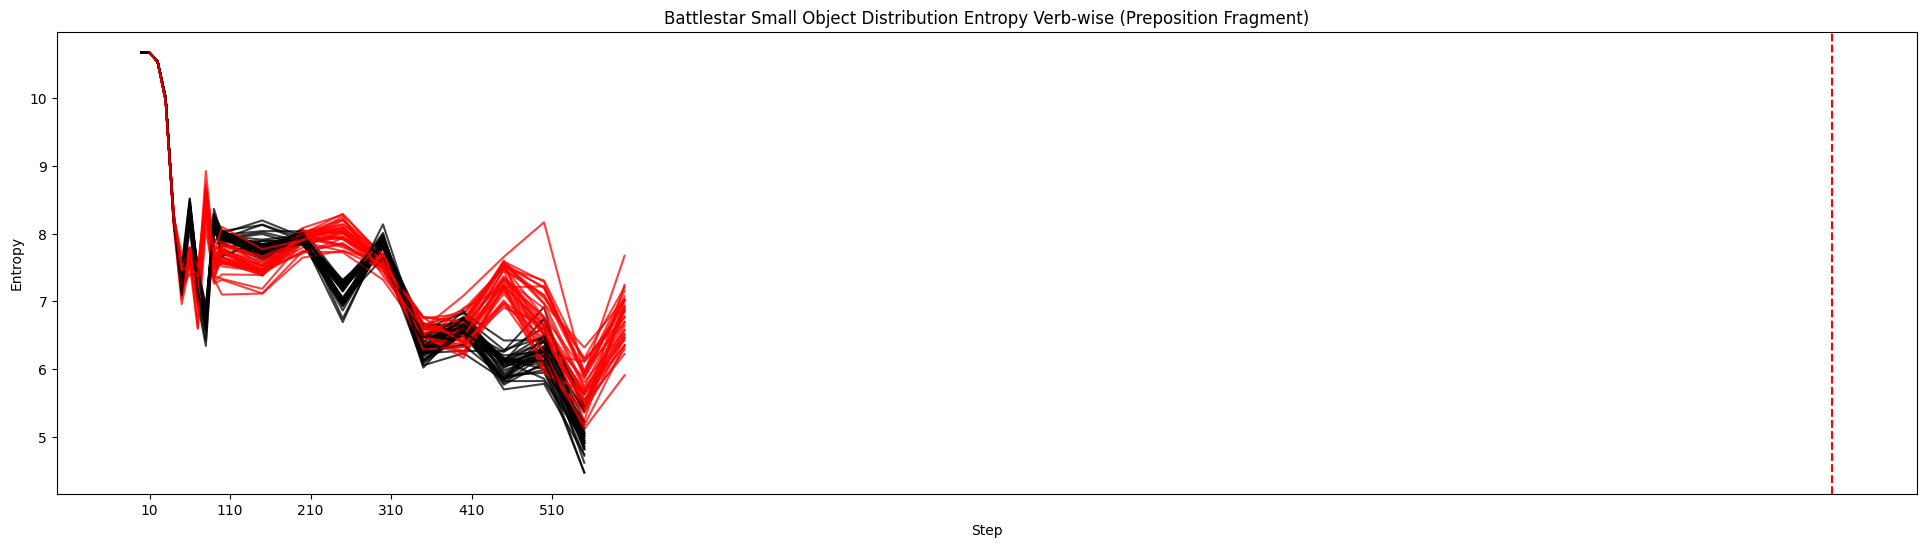

In [79]:
plot_pair_training_curve(data_path1, data_path2, "Battlestar Small Object Distribution Entropy Verb-wise (Preposition Fragment)", metric_name="Entropy", labels=["Ditransitive", "Motion"], x_max=20)

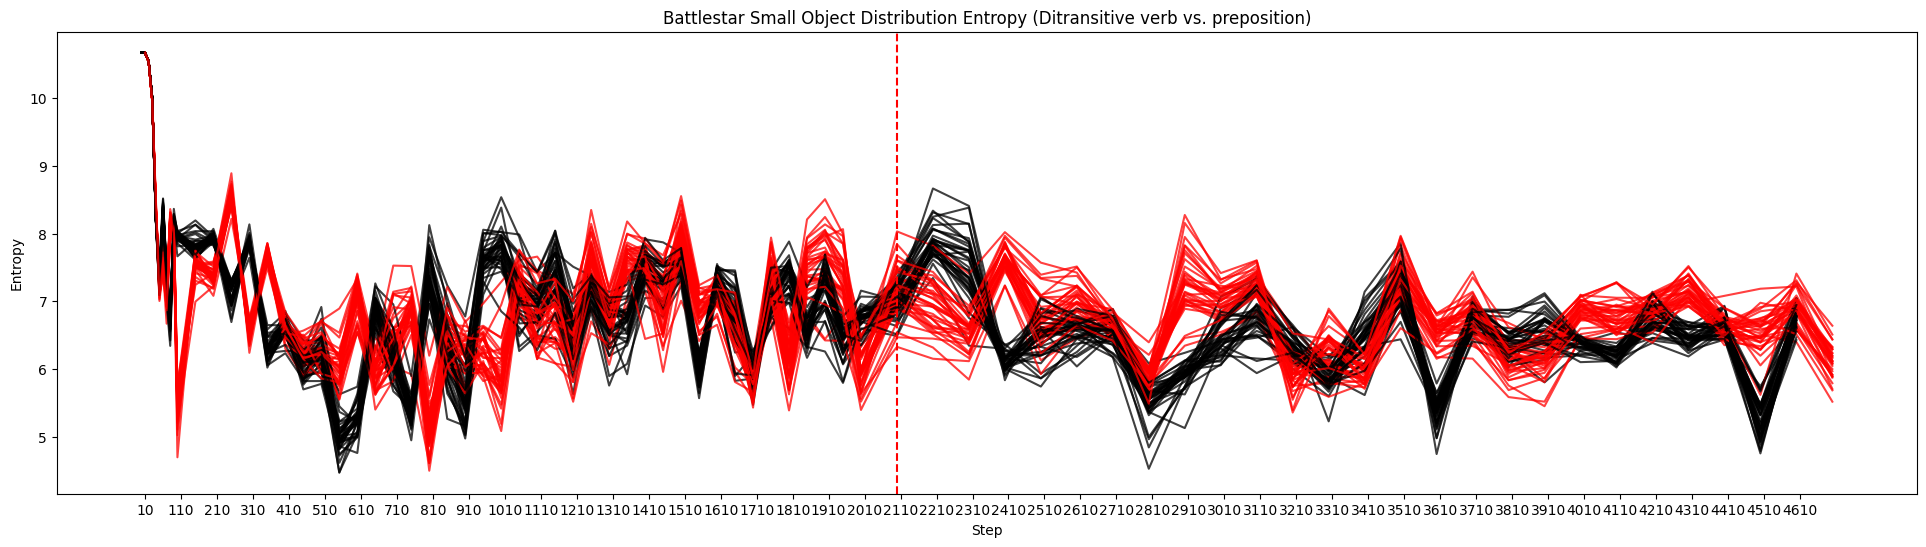

In [11]:
datapath_1 = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"
datapath_2 = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/verb_fragment/battlestar_small.object_distribution.entropy.verb_fragment.verb_wise.tsv"

plot_pair_training_curve(datapath_1, datapath_2, "Battlestar Small Object Distribution Entropy (Ditransitive verb vs. preposition)", metric_name="Entropy", labels=["Ditransitive", "Motion"], x_max=75, normalize=False, log=False)

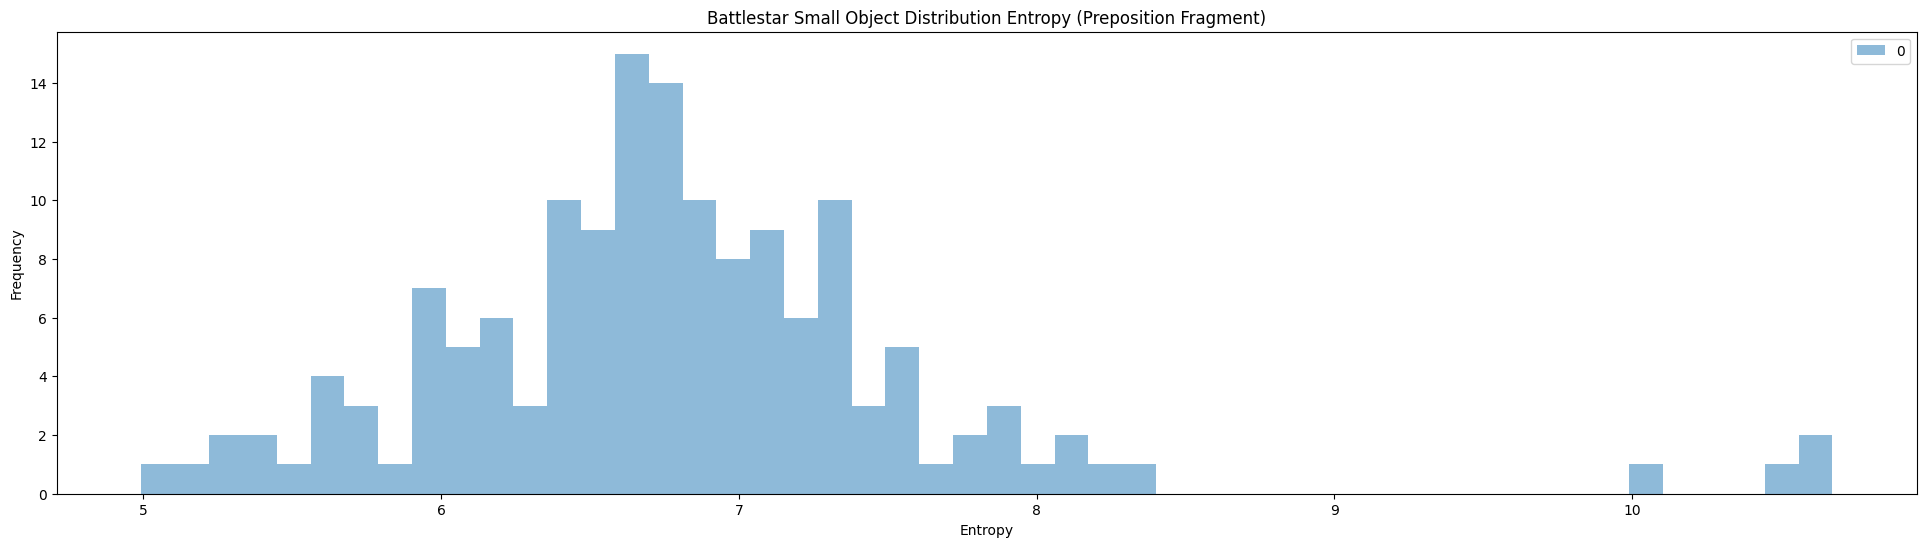

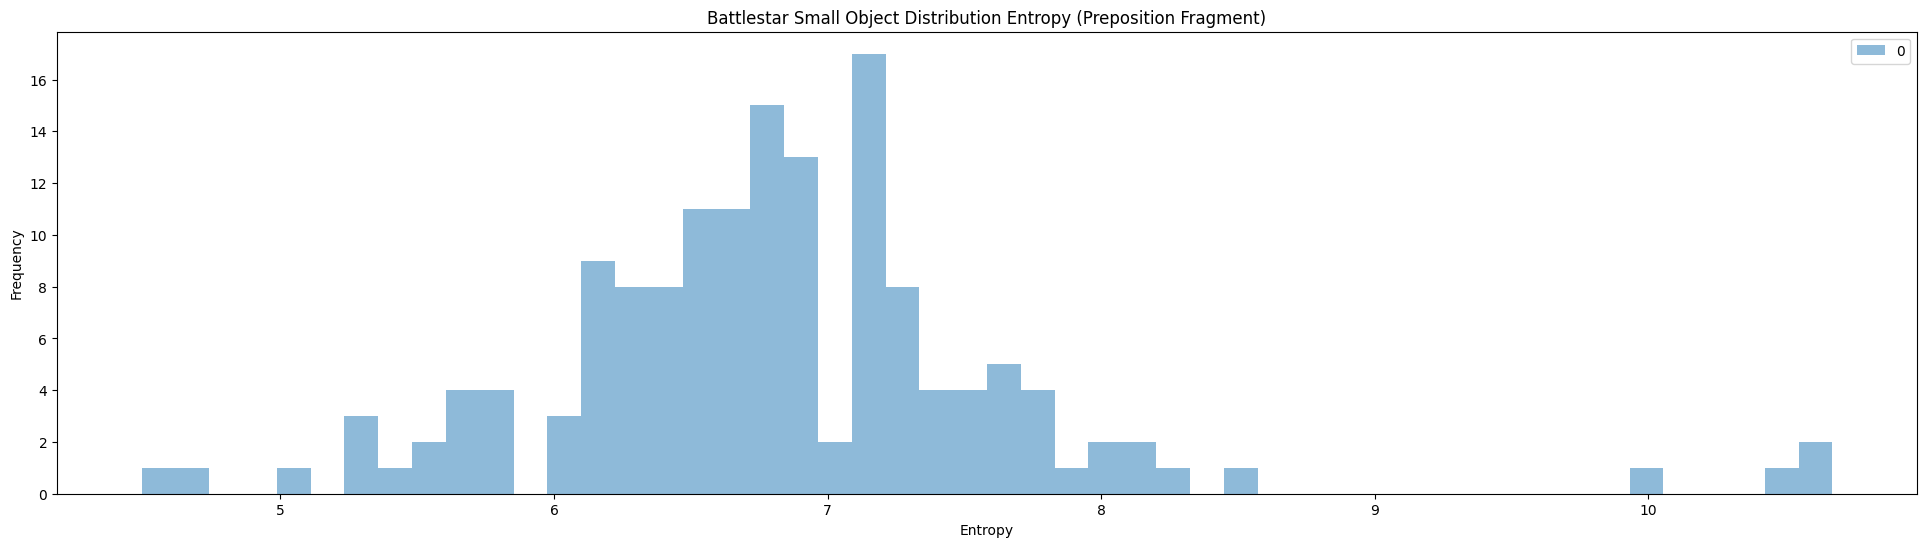

In [11]:
# plot the samples of one line on a single histogram

def plot_histogram(data_path, title, metric_name="Entropy", x_max=None):
    df = pd.read_csv(data_path, sep="\t", index_col=0)
    df = df.apply(pd.to_numeric, errors='coerce')
    plt.figure(figsize=(24, 6))
    for index, row in df.iterrows():
        x, y = [int(x) for x in df.columns], row
        if x_max is not None:
            x = x[:x_max]
            y = y[:x_max]
        plt.hist(y, bins=50, alpha=0.5, label=f'{index}')
    plt.xlabel(metric_name)
    plt.ylabel('Frequency')
    plt.title(title)
    plt.legend()
    plt.show()

datapath_1 = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.tsv"
datapath_2 = "/sailhome/jjian/projects/abstraction/results/wikitext/motion/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.tsv"

plot_histogram(datapath_1, "Battlestar Small Object Distribution Entropy (Preposition Fragment)", metric_name="Entropy", x_max=150)
plot_histogram(datapath_2, "Battlestar Small Object Distribution Entropy (Preposition Fragment)", metric_name="Entropy", x_max=150)

In [22]:
import pandas as pd
import itertools
from scipy.stats import ttest_ind, ttest_rel, pearsonr
import seaborn as sns

def pairwise_t_tests(df):
    # Store the results in a list of tuples (row1, row2, t-stat, p-value)
    results = []

    # Get all possible pairs of row indices
    row_pairs = list(itertools.combinations(df.index, 2))

    for row1, row2 in row_pairs:
        # Perform t-test between the two rows
        corr, p_value = pearsonr(df.loc[row1], df.loc[row2])  # Assuming unequal variances

        # Append the results as a tuple (row1, row2, t_stat, p_value)
        results.append((row1, row2, corr, p_value))

    # Convert results to a DataFrame for easy viewing
    results_df = pd.DataFrame(results, columns=["Row1", "Row2", "T-Statistic", "P-Value"])

    return results_df

In [26]:
df

,0,10,20,30,40,50,60,70,80,90,...,11300,11400,11500,11600,11700,11800,11900,12000,12100,12200
allocate,10.671546,10.672042,10.545846,9.993619,8.183790,7.155650,8.222540,7.435136,6.740797,7.866699,...,6.745297,6.581736,6.621165,6.333377,7.296504,5.786130,6.401934,6.611165,5.910204,5.648519
allot,10.672038,10.673279,10.545263,9.993244,8.205747,7.353964,8.414613,7.263768,6.640215,8.134903,...,6.889169,6.875493,6.855403,6.342082,7.503203,6.489140,6.801383,7.101895,6.173180,6.118401
ask,10.671718,10.672702,10.545249,10.008706,8.216486,7.234960,8.247984,7.035786,6.422951,8.059896,...,6.902686,6.836855,6.637170,5.873324,7.366161,5.903755,6.782000,7.134271,5.960737,6.265952
assign,10.671454,10.672050,10.546152,10.008161,8.238631,7.356492,8.419698,7.443746,6.709202,8.269733,...,6.823810,7.029727,6.644181,6.370644,7.453081,6.204590,6.763573,7.019678,6.002747,6.365071
award,10.671295,10.672172,10.546303,10.008546,8.200816,7.254860,8.203927,7.389397,6.709273,8.067332,...,6.639257,6.638888,6.568719,6.074820,7.319837,6.644878,6.723860,6.776459,6.023426,5.968770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trudge,10.672160,10.674022,10.545890,9.968779,8.137470,7.168602,7.808851,6.313867,8.497921,7.034954,...,7.192305,5.897866,4.611773,6.932032,5.444101,5.773697,7.133397,6.467045,5.758975,NaN
tumble,10.670819,10.672450,10.543737,9.988920,8.407283,7.560771,7.825212,7.625613,8.613076,7.716660,...,6.555337,6.687114,7.062523,7.156759,6.910853,6.534009,6.843687,7.180064,6.293609,NaN
vault,10.671421,10.671619,10.541739,9.973307,8.227606,8.045238,8.680086,8.087573,8.886394,8.268006,...,5.227860,4.694045,4.848612,5.159071,5.097272,6.193335,4.872371,4.303173,4.741861,NaN
walk,10.671589,10.672917,10.543368,9.967542,8.203158,7.324137,7.641571,7.204983,8.556173,7.634978,...,6.597936,6.035037,7.248079,7.163898,6.667264,6.371313,6.692197,6.455487,6.170835,NaN


In [91]:
datapath_1 = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"
datapath_2 = "/sailhome/jjian/projects/abstraction/results/wikitext/motion/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"

df1 = pd.read_csv(datapath_1, sep="\t", index_col=0)
df1 = df1.apply(pd.to_numeric, errors='coerce')
df1 = df1.iloc[:, :-1]
df2 = pd.read_csv(datapath_2, sep="\t", index_col=0)
df2 = df2.apply(pd.to_numeric, errors='coerce')
df2 = df2.loc[common_motion_list]
# combine the two dataframes
df = pd.concat([df1, df2], axis=0)
# perform a paired t-test
df_transposed = df.T
corr_matrix = df_transposed.corr(method='pearson')


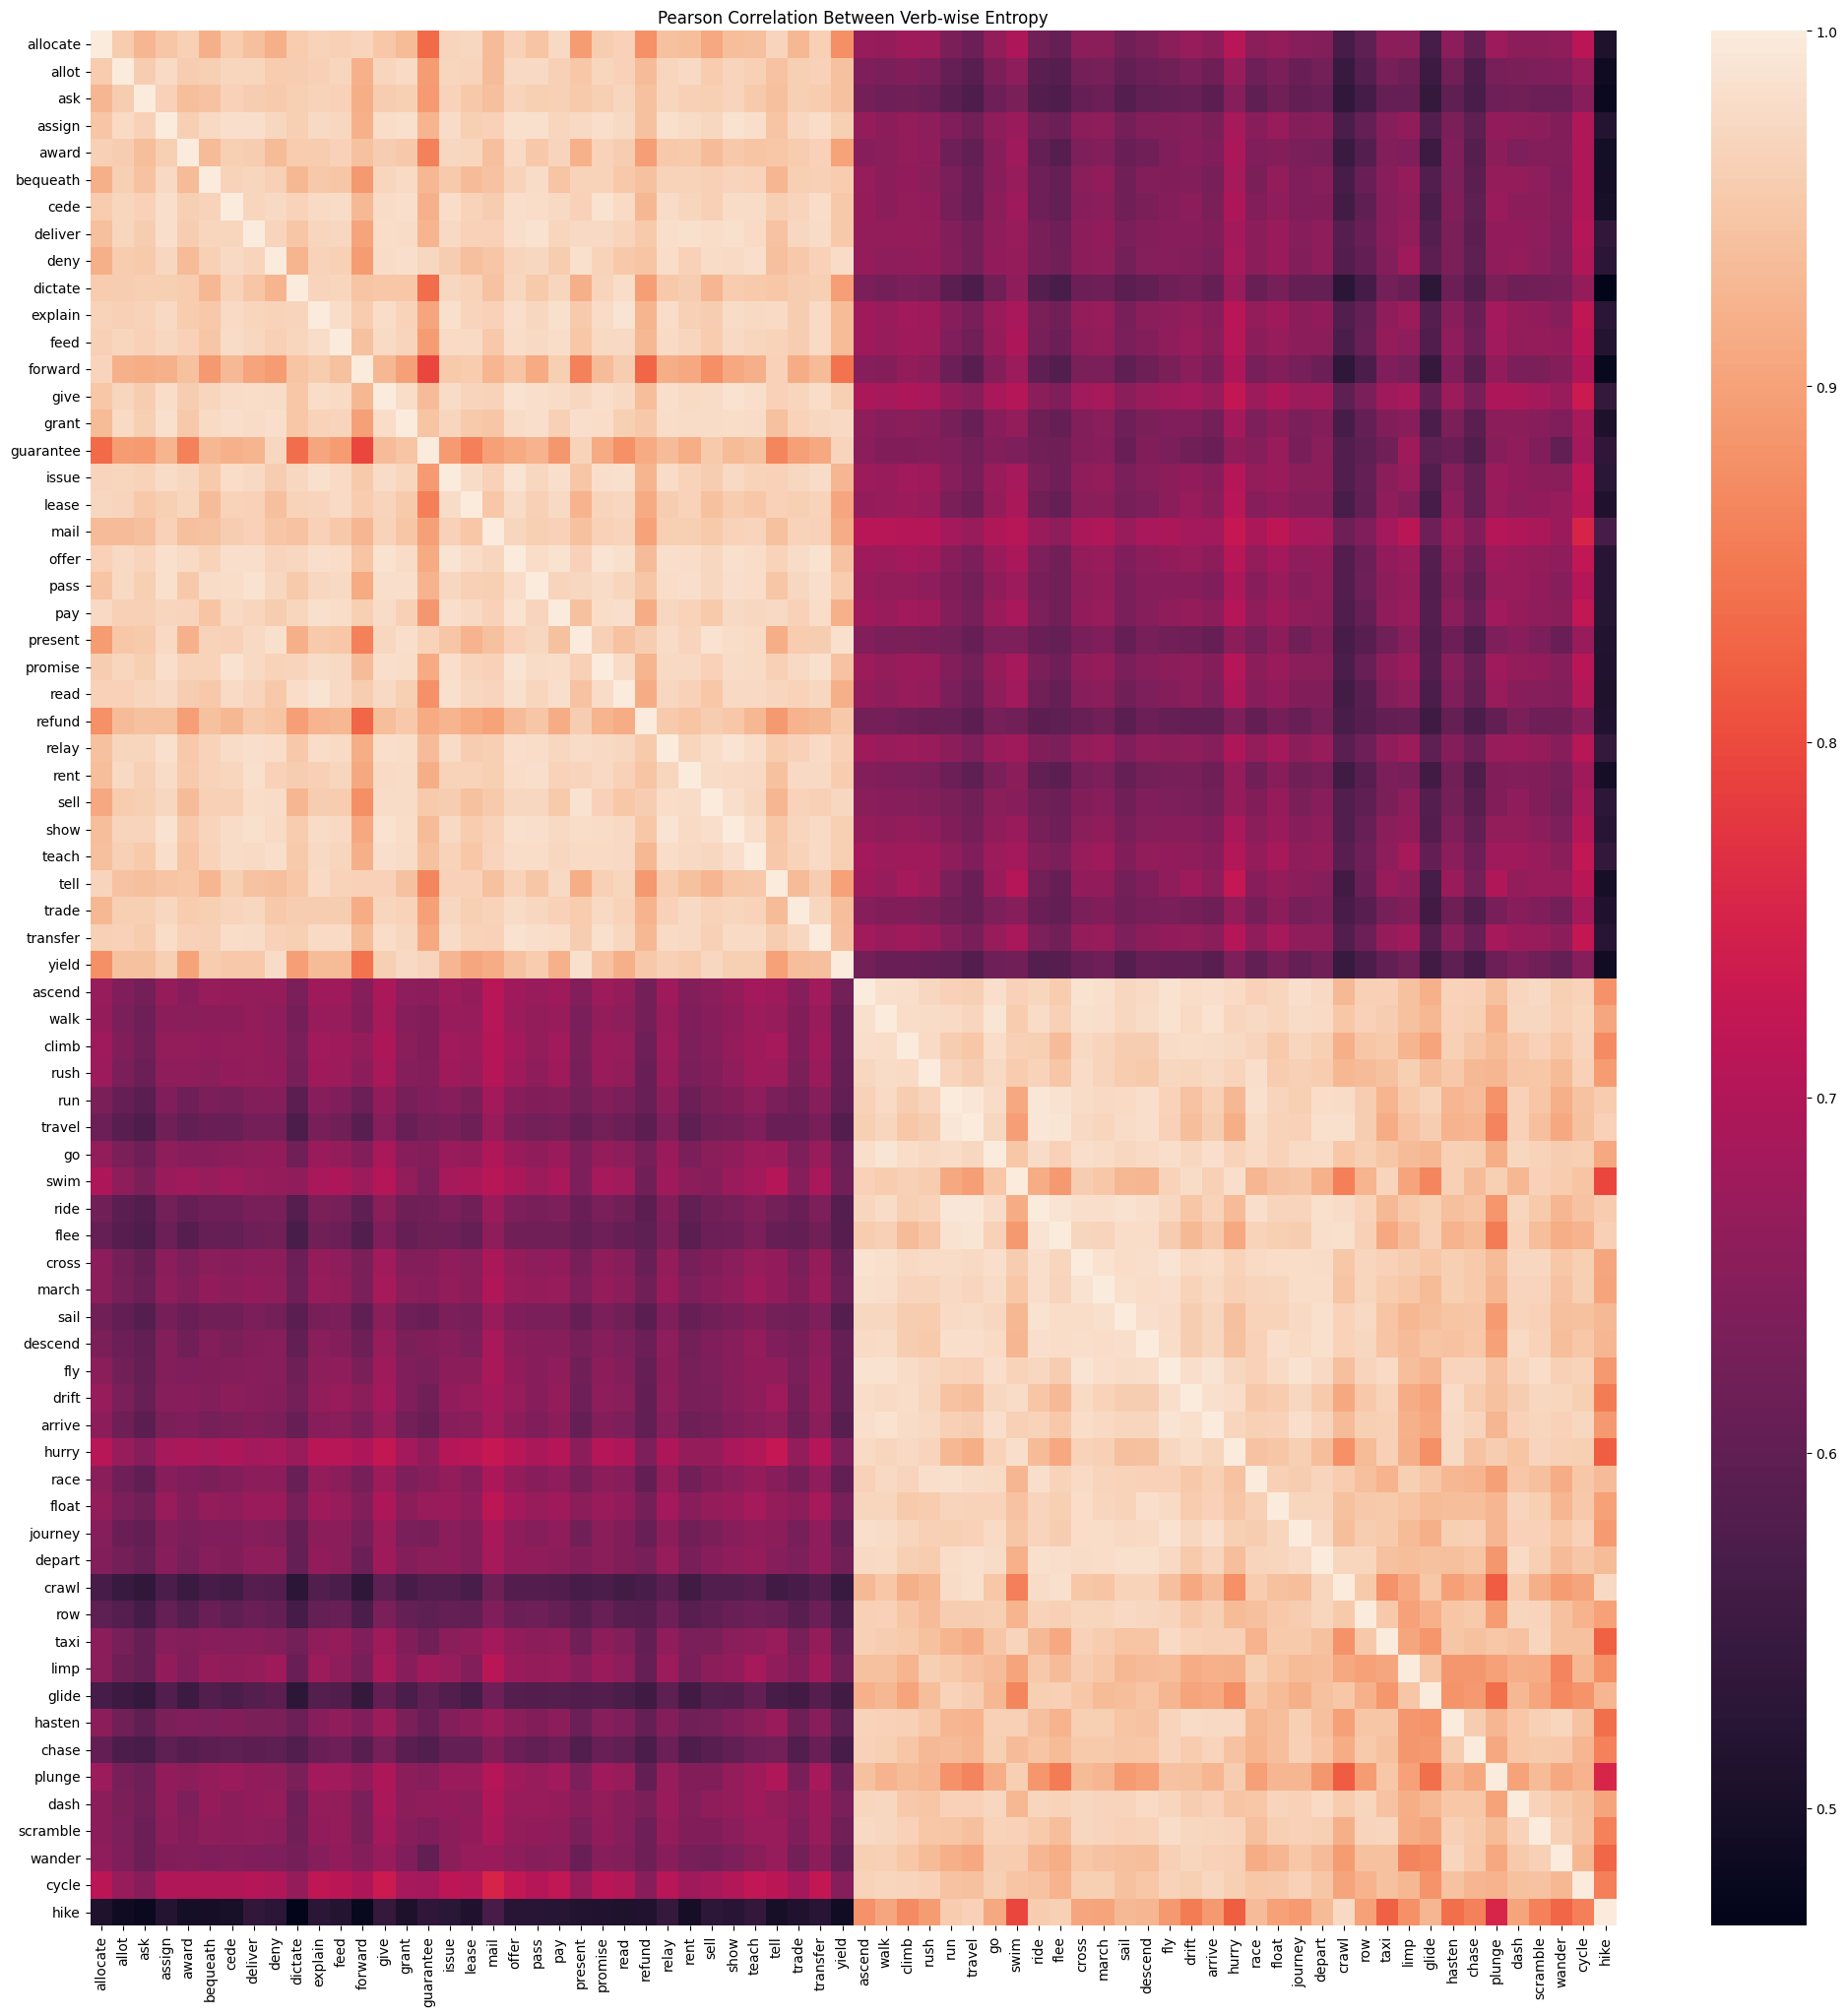

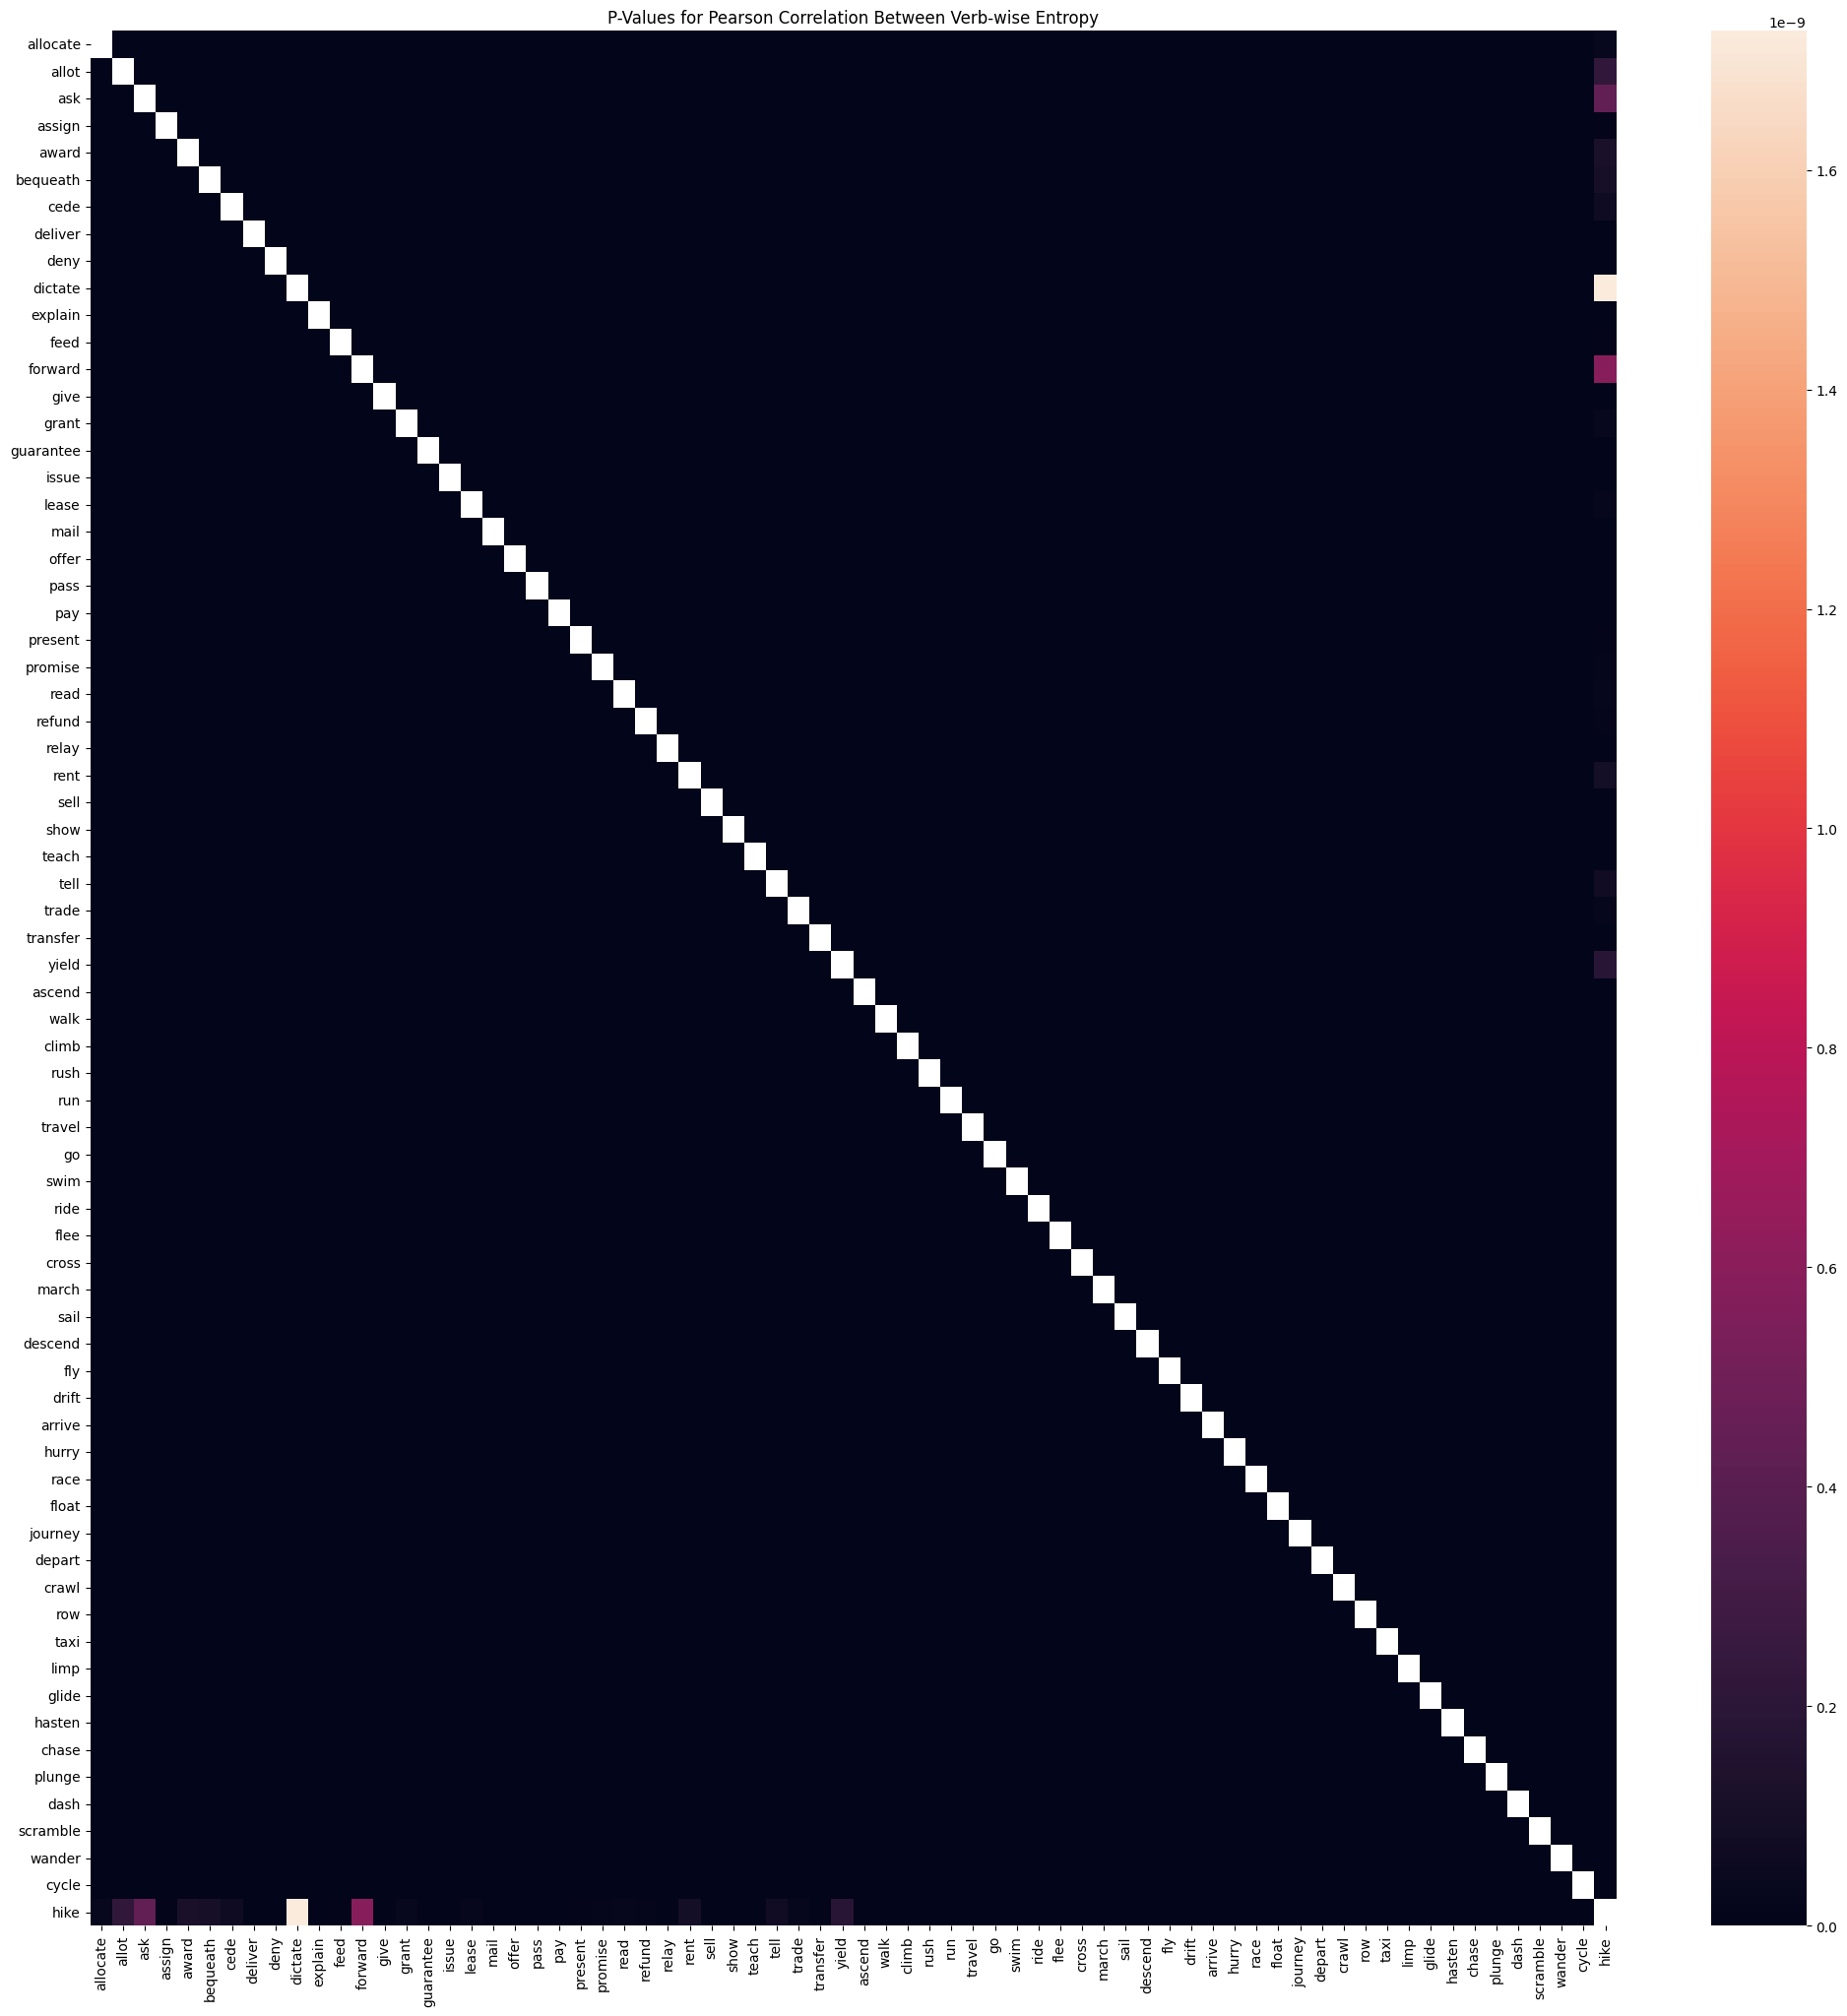

In [93]:
plt.figure(figsize=(25, 25))
sns.heatmap(corr_matrix, annot=False)
plt.title('Pearson Correlation Between Verb-wise Entropy')
plt.show()

pval_matrix = pd.DataFrame(np.zeros((df_transposed.shape[1], df_transposed.shape[1])), 
                           columns=df_transposed.columns, index=df_transposed.columns)

# Step 4: Calculate p-values for each pair of columns (time series)
for col1 in df_transposed.columns:
    for col2 in df_transposed.columns:
        if col1 != col2:
            corr, pval = pearsonr(df_transposed[col1], df_transposed[col2])
            pval_matrix.loc[col1, col2] = pval
        else:
            pval_matrix.loc[col1, col2] = np.nan  # Set diagonal to NaN, no p-value for self-correlation

plt.figure(figsize=(25, 25))
sns.heatmap(pval_matrix, annot=False)
plt.title('P-Values for Pearson Correlation Between Verb-wise Entropy')
plt.show()

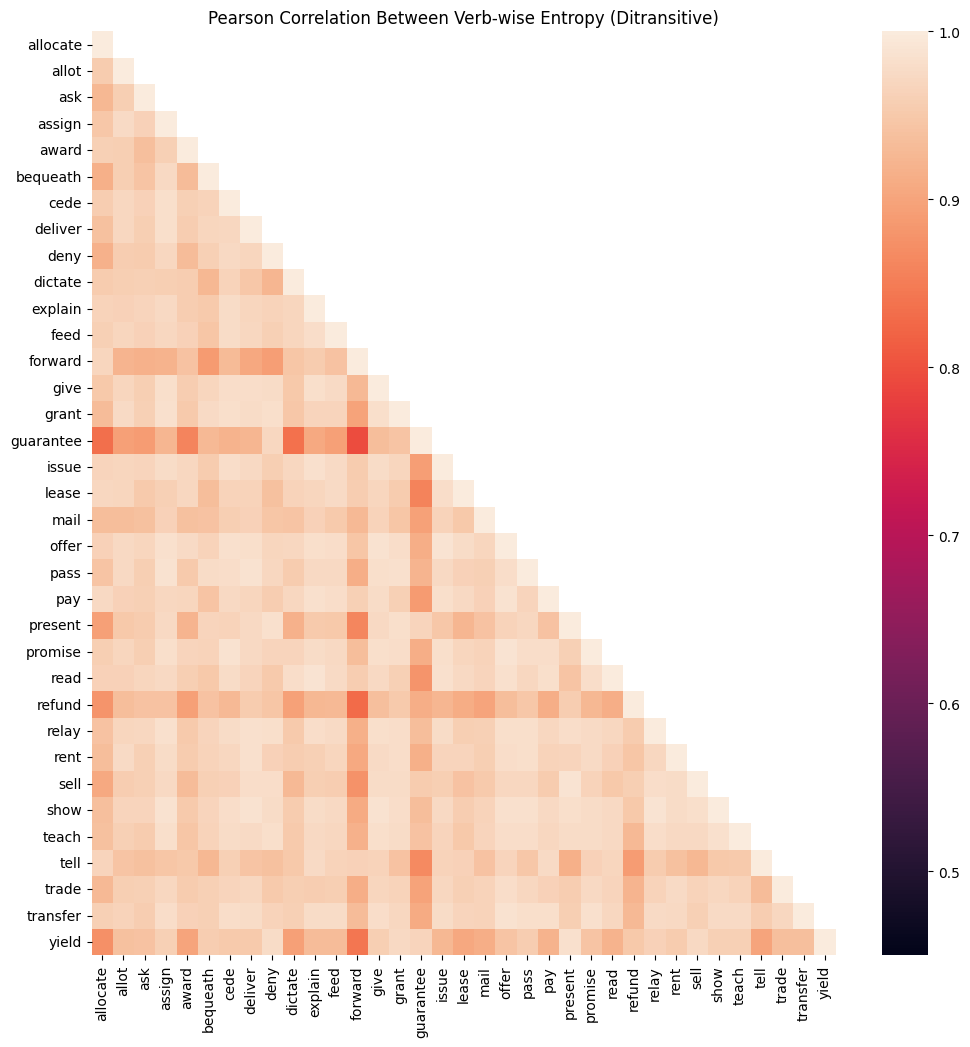

In [44]:

df1 = pd.read_csv(datapath_1, sep="\t", index_col=0)
df1 = df1.apply(pd.to_numeric, errors='coerce')
df1_transposed = df1.T
corr_matrix = df1_transposed.corr(method='pearson')

# sort the correlation matrix rows by sum
# corr_matrix['sum'] = corr_matrix.sum(axis=1)
# corr_matrix = corr_matrix.sort_values(by='sum', ascending=False)
# corr_matrix = corr_matrix.drop(columns=['sum'])

# show only the lower triangular part
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))
corr_matrix = corr_matrix.where(mask)


plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=False, vmin=0.45, vmax=1)
plt.title('Pearson Correlation Between Verb-wise Entropy (Ditransitive)')
plt.show()

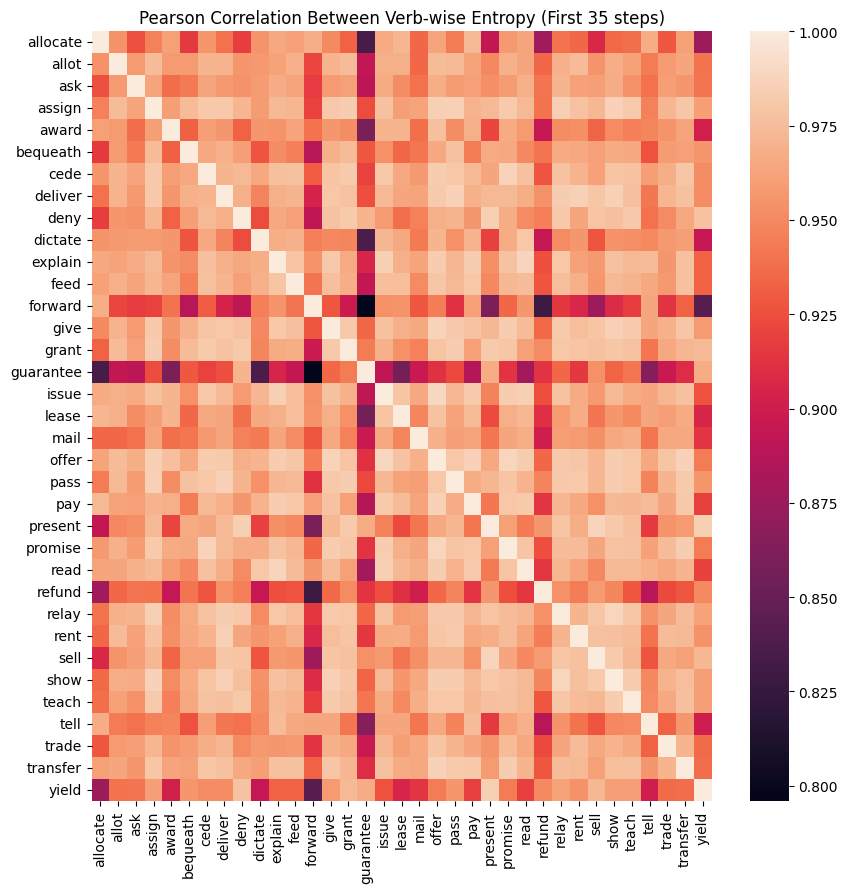

In [49]:
datapath_1 = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"
datapath_2 = "/sailhome/jjian/projects/abstraction/results/wikitext/motion/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"

df1 = pd.read_csv(datapath_1, sep="\t", index_col=0)
df1 = df1.apply(pd.to_numeric, errors='coerce')
df2 = pd.read_csv(datapath_2, sep="\t", index_col=0)
df2 = df2.apply(pd.to_numeric, errors='coerce')
df2 = df2.loc[common_motion_list]
# combine the two dataframes
df = pd.concat([df1, df2], axis=0)
# take only the first half
df = df.iloc[:35]
# perform a paired t-test
df_transposed = df.T
corr_matrix = df_transposed.corr(method='pearson')
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=False)
plt.title('Pearson Correlation Between Verb-wise Entropy (First 35 steps)')
plt.show()

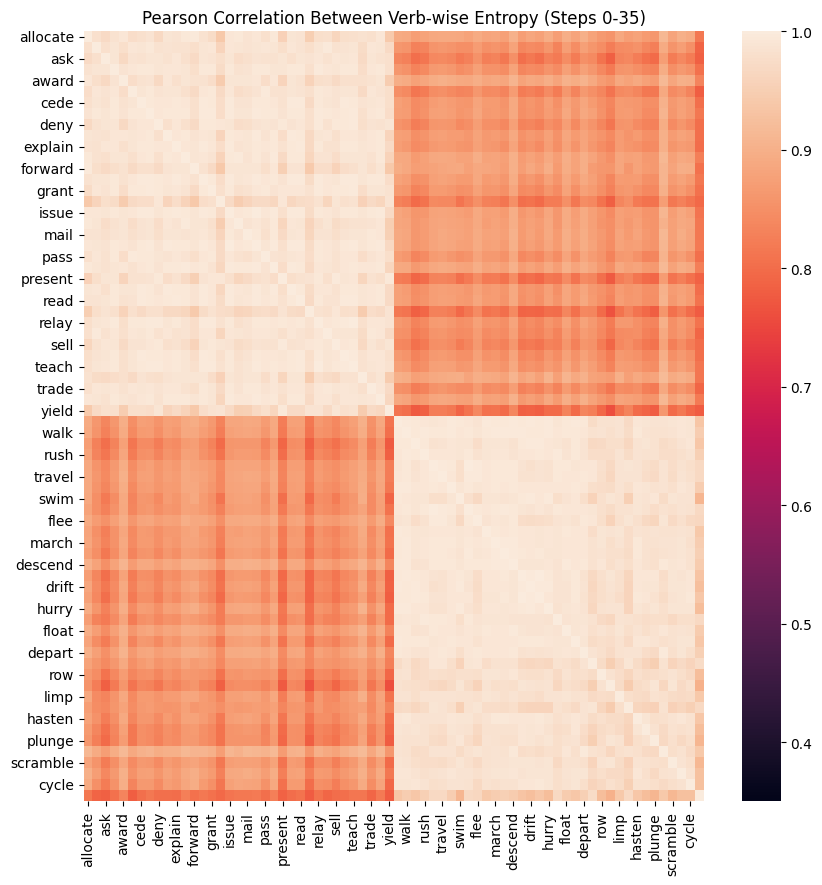

In [80]:
datapath_1 = "/sailhome/jjian/projects/abstraction/results/wikitext/ditransitive/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"
datapath_2 = "/sailhome/jjian/projects/abstraction/results/wikitext/motion/preposition_fragment/battlestar_small.object_distribution.entropy.preposition_fragment.verb_wise.tsv"

df1 = pd.read_csv(datapath_1, sep="\t", index_col=0)
df1 = df1.apply(pd.to_numeric, errors='coerce')
df2 = pd.read_csv(datapath_2, sep="\t", index_col=0)
df2 = df2.apply(pd.to_numeric, errors='coerce')
df2 = df2.loc[common_motion_list]
# combine the two dataframes
df = pd.concat([df1, df2], axis=0)
# take only the first half of the rows
df = df.iloc[:, :35]
# perform a paired t-test
df_transposed = df.T
corr_matrix = df_transposed.corr(method='pearson')
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=False, vmin=0.35, vmax=1)
plt.title('Pearson Correlation Between Verb-wise Entropy (Steps 0-35)')
plt.show()

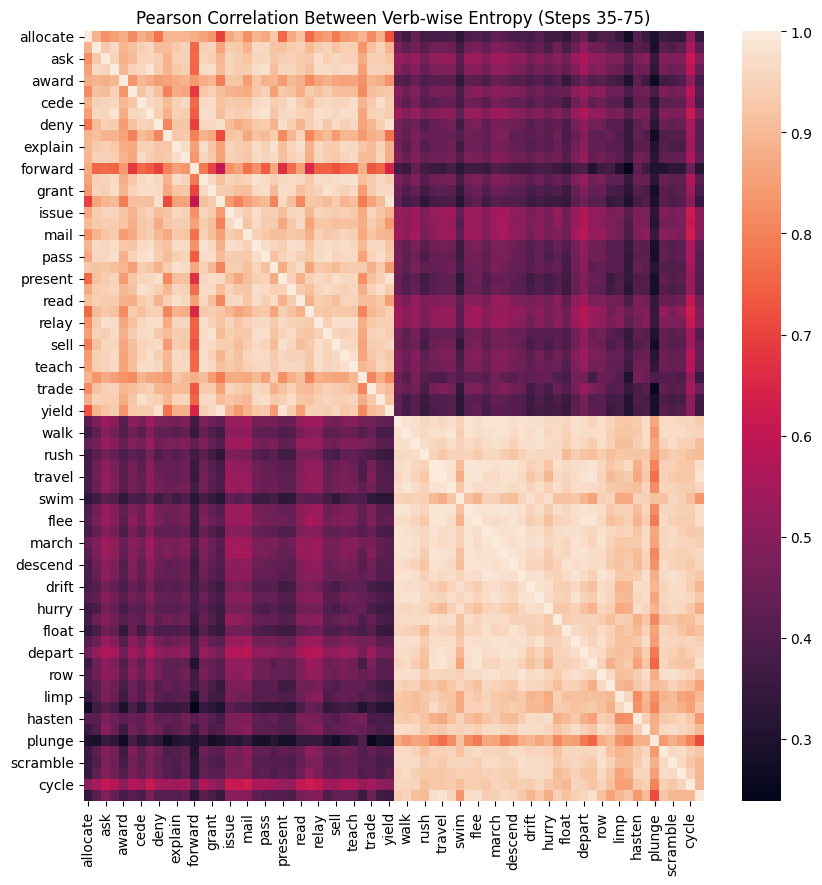

In [69]:
df = pd.concat([df1, df2], axis=0)
df = df.iloc[:, 35:75]
# perform a paired t-test
df_transposed = df.T
corr_matrix = df_transposed.corr(method='pearson')
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=False)
plt.title('Pearson Correlation Between Verb-wise Entropy (Steps 35-75)')
plt.show()

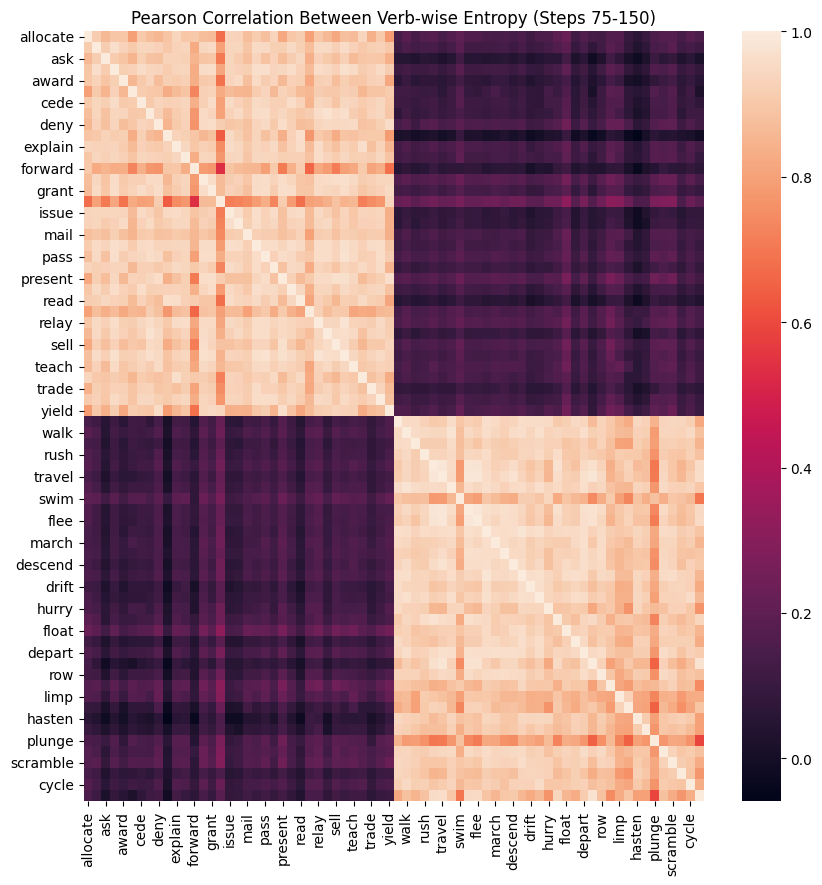

In [68]:
df = pd.concat([df1, df2], axis=0)
df = df.iloc[:, 75:150]
# perform a paired t-test
df_transposed = df.T
corr_matrix = df_transposed.corr(method='pearson')
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=False)
plt.title('Pearson Correlation Between Verb-wise Entropy (Steps 75-150)')
plt.show()